# 06 · Decision Trees and CART

A decision tree predicts by asking a sequence of yes/no questions about single features ("is $x_3 \le 2.5$?") until it reaches a leaf that holds a prediction. **CART** (Classification And Regression Trees, Breiman et al. 1984) is the standard algorithm to grow them, and it is what scikit-learn implements.

**Contents**

1. The model: recursive axis-aligned partitions
2. What a leaf predicts (and why)
3. Impurity measures: Gini, entropy, variance
4. Choosing a split: impurity decrease
5. The CART algorithm (greedy, recursive)
6. A worked example by hand
7. Implementation from scratch
8. Regression trees
9. Overfitting, stopping rules and cost-complexity pruning
10. Properties: strengths, weaknesses, feature importance

In [1]:
import numpy as np
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.dpi": 90, "axes.grid": True, "grid.alpha": 0.3,
                     "axes.spines.top": False, "axes.spines.right": False})
rng = np.random.default_rng(0)

## 1. The model

A (binary) tree splits the input space recursively. Each **internal node** $t$ stores a split $(j, s)$: feature index $j$ and threshold $s$. Samples with $x_j\le s$ go left, the rest go right. Each **leaf** $\ell$ stores a constant prediction $c_\ell$. The tree therefore divides the space into axis-aligned boxes $R_1,\dots,R_L$ (the leaves) and predicts

$$
h(\mathbf{x}) = \sum_{\ell=1}^L c_\ell\,\mathbb{1}[\mathbf{x}\in R_\ell],
$$

a **piecewise-constant** function. Its "parameters" are the tree structure, the splits $(j,s)$ and the leaf values $c_\ell$. Unlike the previous models there is no smooth loss in continuous parameters, so no gradient descent: the structure is found by a **greedy search**.

Notation for this notebook: $S_t$ is the set of training examples reaching node $t$, $N_t = |S_t|$, and a split sends them to $S_L = \{i\in S_t: x^{(i)}_j\le s\}$ and $S_R = S_t\setminus S_L$.

## 2. What a leaf predicts

Given the examples in a leaf, the constant $c$ that minimises the loss on them is:

- **Squared error (regression)**: $c = \bar{y}$, the mean.
  *Proof:* $\frac{d}{dc}\sum_i(y^{(i)}-c)^2 = -2\sum_i(y^{(i)}-c) = 0 \Rightarrow c = \frac{1}{N}\sum_i y^{(i)}$.
- **Absolute error**: the median.
- **0–1 loss (classification)**: the **majority class** (predicting class $k$ is wrong for a fraction $1-p_k$ of the leaf, smallest when $p_k$ is largest).
- **Log-loss**: the **class proportions** $\hat p_k = N_k/N$ as probabilities (the MLE of a categorical distribution). This is what `predict_proba` returns.

## 3. Impurity measures

A good split produces children that are "pure" (mostly one class, or targets close to their mean). With $p_k$ the fraction of class $k$ in node $t$:

| Measure | Formula | Binary case ($p$ = fraction of class 1) | Max (binary) |
|---|---|---|---|
| **Gini** | $I_G = \sum_k p_k(1-p_k) = 1 - \sum_k p_k^2$ | $2p(1-p)$ | 0.5 |
| **Entropy** | $I_H = -\sum_k p_k\log_2 p_k$ | $-p\log_2p - (1-p)\log_2(1-p)$ | 1 bit |
| Misclassification | $I_E = 1 - \max_k p_k$ | $1-\max(p,1-p)$ | 0.5 |
| **Variance** (regression) | $I_V = \frac{1}{N_t}\sum_{i\in S_t}(y^{(i)} - \bar y_t)^2$ | – | – |

All are 0 for a pure node and maximal for a uniform mix.

**Interpretations.**
- *Gini* = probability that two examples drawn at random (with replacement) from the node have **different** labels: $P(\text{same}) = \sum_k p_k^2$. Also the expected error of a classifier that predicts at random with the node's class proportions.
- *Entropy* = expected number of bits to encode the label; the resulting decrease is called **information gain**.
- In practice Gini and entropy give almost the same trees. Gini is the CART default (a bit cheaper, no logarithm).

**Why not use misclassification error to grow the tree?** It is piecewise linear in $p$, so many useful splits don't change it at all. Example: a node with 400 of class A and 400 of class B.
- Split 1: (300 A, 100 B) | (100 A, 300 B). Split 2: (200 A, 400 B) | (200 A, 0 B).
- Misclassification: split 1 gives $\frac12\cdot\frac14 + \frac12\cdot\frac14 = 0.25$; split 2 gives $\frac{600}{800}\cdot\frac13 + \frac{200}{800}\cdot 0 = 0.25$. A tie.
- Gini: in split 1 each child has $2\cdot\tfrac34\cdot\tfrac14 = 0.375$, so the weighted impurity is $0.375$; split 2 gives $\tfrac{600}{800}\cdot2\cdot\tfrac13\cdot\tfrac23 + \tfrac{200}{800}\cdot 0 = 0.333$. Gini prefers split 2, which creates a **pure** node that needs no further splitting.

Gini and entropy are **strictly concave** in $p$, which is what guarantees that any split that changes the class proportions strictly decreases the weighted impurity (by Jensen's inequality, the parent's impurity is the concave function evaluated at the weighted average of the children's proportions).

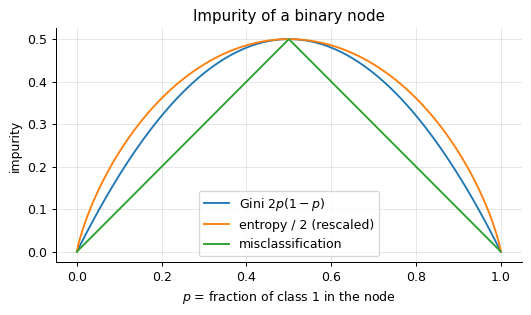

In [2]:
p = np.linspace(1e-6, 1 - 1e-6, 400)
gini = 2 * p * (1 - p); ent = -(p * np.log2(p) + (1 - p) * np.log2(1 - p)); mis = 1 - np.maximum(p, 1 - p)
plt.figure(figsize=(6, 3.6))
plt.plot(p, gini, label="Gini $2p(1-p)$"); plt.plot(p, ent / 2, label="entropy / 2 (rescaled)"); plt.plot(p, mis, label="misclassification")
plt.xlabel("$p$ = fraction of class 1 in the node"); plt.ylabel("impurity"); plt.legend(); plt.title("Impurity of a binary node")
plt.tight_layout(); plt.show()

## 4. Choosing a split: impurity decrease

For a candidate split $(j,s)$ of node $t$:

$$
\Delta I(j,s) = I(S_t) - \Big(\frac{N_L}{N_t}I(S_L) + \frac{N_R}{N_t}I(S_R)\Big)
$$

(parent impurity minus the **size-weighted** average impurity of the children). CART picks the $(j,s)$ with the largest $\Delta I$.

**Regression: variance reduction = squared-error reduction.** Since $N\cdot I_V(S) = \sum_{i\in S}(y^{(i)}-\bar y_S)^2 = \mathrm{SSE}(S)$ (the squared error of predicting the mean, which is the optimal leaf value),

$$
N_t\,\Delta I_V = \mathrm{SSE}(S_t) - \big[\mathrm{SSE}(S_L) + \mathrm{SSE}(S_R)\big].
$$

So maximising the variance decrease is **exactly** choosing the split that most reduces the training squared error of the tree. Similarly, the entropy criterion is the decrease of the training log-loss (times $\log 2$) with leaves predicting class proportions.

**Which thresholds to try?** Only values between consecutive distinct sorted values of $x_j$ change the partition, so we try the midpoints. With the feature sorted once, all candidate splits of that feature can be scored in one pass by updating class counts incrementally: $O(N_t\log N_t)$ per feature per node.

## 5. The CART algorithm

```
grow(S, depth):
    if stopping rule holds (node pure, N < min_samples_split, depth = max_depth, ...):
        return Leaf(value = mean / majority class / class proportions of S)
    for each feature j, for each candidate threshold s:
        compute ΔI(j, s)
    pick (j*, s*) with the largest ΔI    (if ΔI < min_impurity_decrease: return Leaf)
    return Node(j*, s*, left = grow(S_L, depth+1), right = grow(S_R, depth+1))
```

- **Greedy**: each split is the best *one-step* choice. It never looks ahead and never revisits a split, so it does not find the optimal tree (which is an NP-hard problem), but it is fast and works well in practice.
- **Recursive**: the same procedure runs independently on each child.
- Prediction: drop $\mathbf{x}$ down the tree, cost $O(\text{depth})$.

## 6. A worked example by hand

Eight examples, one feature:

| $x$ | 1 | 2 | 3 | 4 | 5 | 6 | 7 | 8 |
|---|---|---|---|---|---|---|---|---|
| $y$ | A | A | A | B | A | B | B | B |

Root: 4 A, 4 B → $I_G = 1 - (0.5^2 + 0.5^2) = 0.5$.

- **Split $x\le3.5$**: left (A,A,A) has $I_G=0$. Right (B,A,B,B,B) has $p_A = 1/5$, so $I_G = 1 - (0.2^2 + 0.8^2) = 0.32$.
  Weighted: $\frac38\cdot0 + \frac58\cdot0.32 = 0.20$ → $\Delta I = 0.30$.
- **Split $x\le4.5$**: left (A,A,A,B) has $I_G = 1-(0.75^2+0.25^2) = 0.375$; right (A,B,B,B) likewise 0.375.
  Weighted: 0.375 → $\Delta I = 0.125$.
- **Split $x\le5.5$**: left (A,A,A,B,A) has $I_G=0.32$, right (B,B,B) has 0. Weighted: $\frac58\cdot0.32 = 0.20$ → $\Delta I = 0.30$ (tie with 3.5).

The best first split is $x\le3.5$ (or the tied $x\le5.5$). The code below checks this.

In [3]:
def gini(y):
    if len(y) == 0: return 0.0
    _, counts = np.unique(y, return_counts=True); p = counts / len(y)
    return 1 - np.sum(p ** 2)

def entropy(y):
    _, counts = np.unique(y, return_counts=True); p = counts / len(y)
    return -np.sum(p * np.log2(p))

def variance(y):
    return np.var(y) if len(y) else 0.0

xw = np.arange(1, 9); yw = np.array(list("AAABABBB"))
for s in np.arange(1.5, 8, 1.0):
    L, R = yw[xw <= s], yw[xw > s]
    dI = gini(yw) - (len(L) * gini(L) + len(R) * gini(R)) / len(yw)
    print(f"split x <= {s}:  Gini decrease = {dI:.3f}")

split x <= 1.5:  Gini decrease = 0.071
split x <= 2.5:  Gini decrease = 0.167
split x <= 3.5:  Gini decrease = 0.300
split x <= 4.5:  Gini decrease = 0.125
split x <= 5.5:  Gini decrease = 0.300
split x <= 6.5:  Gini decrease = 0.167
split x <= 7.5:  Gini decrease = 0.071


## 7. Implementation from scratch

A compact CART that handles classification (Gini/entropy, majority leaf) and regression (variance, mean leaf).

In [4]:
class Node:
    def __init__(self, value, j=None, s=None, left=None, right=None, n=0, gain=0.0):
        self.value, self.j, self.s, self.left, self.right, self.n, self.gain = value, j, s, left, right, n, gain
    def is_leaf(self): return self.left is None

def best_split(X, y, impurity):
    best = (None, None, 0.0)                       # (j, s, gain)
    parent = impurity(y); N = len(y)
    for j in range(X.shape[1]):
        values = np.unique(X[:, j])
        for s in (values[:-1] + values[1:]) / 2:     # midpoints between distinct values
            mask = X[:, j] <= s
            gain = parent - (mask.sum() * impurity(y[mask]) + (~mask).sum() * impurity(y[~mask])) / N
            if gain > best[2]:
                best = (j, s, gain)
    return best

def grow(X, y, impurity, leaf_value, depth=0, max_depth=5, min_samples_split=2):
    node = Node(leaf_value(y), n=len(y))
    if depth >= max_depth or len(y) < min_samples_split or impurity(y) == 0:
        return node
    j, s, gain = best_split(X, y, impurity)
    if j is None:
        return node
    mask = X[:, j] <= s
    node.j, node.s, node.gain = j, s, gain
    node.left = grow(X[mask], y[mask], impurity, leaf_value, depth + 1, max_depth, min_samples_split)
    node.right = grow(X[~mask], y[~mask], impurity, leaf_value, depth + 1, max_depth, min_samples_split)
    return node

def predict_one(node, x):
    while not node.is_leaf():
        node = node.left if x[node.j] <= node.s else node.right
    return node.value

majority = lambda y: np.bincount(y).argmax()
predict = lambda tree, X: np.array([predict_one(tree, x) for x in X])

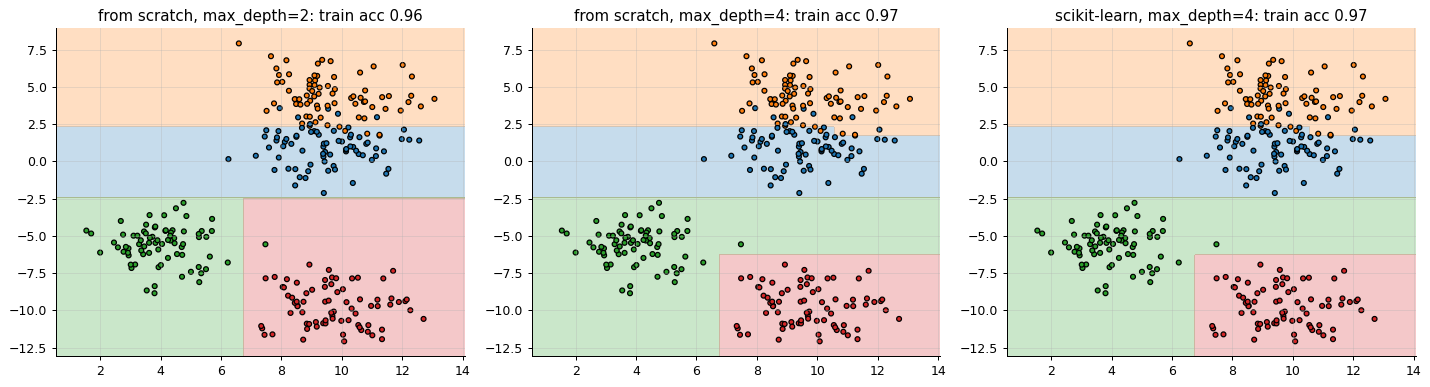

In [5]:
from sklearn.datasets import make_blobs
from sklearn.tree import DecisionTreeClassifier

Xb, yb = make_blobs(n_samples=300, centers=4, cluster_std=1.3, random_state=4)
g1, g2 = np.meshgrid(np.linspace(Xb[:, 0].min() - 1, Xb[:, 0].max() + 1, 250), np.linspace(Xb[:, 1].min() - 1, Xb[:, 1].max() + 1, 250))
G = np.c_[g1.ravel(), g2.ravel()]

fig, axes = plt.subplots(1, 3, figsize=(16, 4.4))
for ax, depth in zip(axes[:2], [2, 4]):
    tree = grow(Xb, yb, gini, majority, max_depth=depth)
    Z = predict(tree, G).reshape(g1.shape)
    ax.contourf(g1, g2, Z, alpha=0.25, levels=[-0.5, 0.5, 1.5, 2.5, 3.5], cmap="tab10", vmin=0, vmax=9)
    ax.scatter(Xb[:, 0], Xb[:, 1], c=yb, cmap="tab10", vmin=0, vmax=9, edgecolor="k", s=15)
    ax.set_title(f"from scratch, max_depth={depth}: train acc {np.mean(predict(tree, Xb) == yb):.2f}")
sk = DecisionTreeClassifier(max_depth=4, random_state=0).fit(Xb, yb)
Z = sk.predict(G).reshape(g1.shape)
axes[2].contourf(g1, g2, Z, alpha=0.25, levels=[-0.5, 0.5, 1.5, 2.5, 3.5], cmap="tab10", vmin=0, vmax=9)
axes[2].scatter(Xb[:, 0], Xb[:, 1], c=yb, cmap="tab10", vmin=0, vmax=9, edgecolor="k", s=15)
axes[2].set_title(f"scikit-learn, max_depth=4: train acc {sk.score(Xb, yb):.2f}")
plt.tight_layout(); plt.show()

In [6]:
def print_tree(node, names, indent=""):
    if node.is_leaf():
        print(f"{indent}predict {node.value}   (n={node.n})"); return
    print(f"{indent}if {names[node.j]} <= {node.s:.2f}:   (n={node.n}, Gini decrease={node.gain:.3f})")
    print_tree(node.left, names, indent + "    ")
    print(f"{indent}else:")
    print_tree(node.right, names, indent + "    ")

print_tree(grow(Xb, yb, gini, majority, max_depth=2), ["x1", "x2"])

if x2 <= -2.45:   (n=300, Gini decrease=0.250)
    if x1 <= 6.78:   (n=150, Gini decrease=0.487)
        predict 2   (n=74)
    else:
        predict 3   (n=76)
else:
    if x2 <= 2.30:   (n=150, Gini decrease=0.376)
        predict 0   (n=73)
    else:
        predict 1   (n=77)


The boundaries are made of **axis-aligned** segments: each split is a line perpendicular to one axis. A diagonal boundary has to be approximated by a staircase.

## 8. Regression trees

Same algorithm with $I_V$ as impurity and the mean as leaf value. The prediction is a step function; each extra level can double the number of steps.

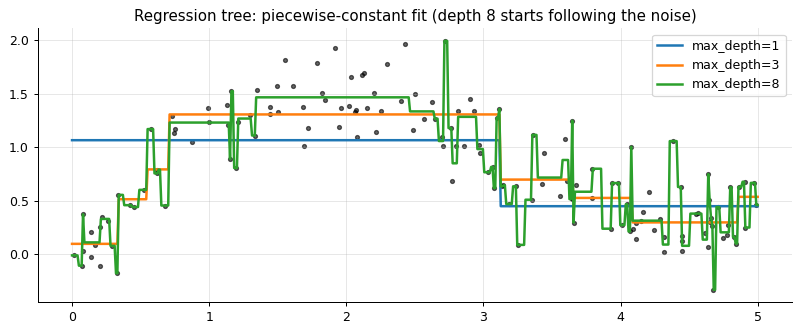

In [7]:
xr = np.sort(rng.uniform(0, 5, 150)); yr = np.sin(xr) + 0.3 * xr + rng.normal(0, 0.25, 150)
gr = np.linspace(0, 5, 500)
plt.figure(figsize=(9, 3.8)); plt.scatter(xr, yr, s=10, color="k", alpha=0.6)
for depth in [1, 3, 8]:
    t = grow(xr[:, None], yr, variance, np.mean, max_depth=depth)
    plt.plot(gr, predict(t, gr[:, None]), lw=2, label=f"max_depth={depth}")
plt.legend(); plt.title("Regression tree: piecewise-constant fit (depth 8 starts following the noise)")
plt.tight_layout(); plt.show()

## 9. Overfitting, stopping rules and pruning

Grown until every leaf is pure, a tree reaches **zero training error** and memorises the noise (one leaf per example in the worst case). It has **low bias and very high variance**. Two ways to control it:

**(a) Pre-pruning (stopping rules)**, the scikit-learn hyperparameters: `max_depth`, `min_samples_split`, `min_samples_leaf`, `max_leaf_nodes`, `min_impurity_decrease`. Simple, but short-sighted: a split that looks useless may enable very good splits below it (XOR is the classic example).

**(b) Cost-complexity pruning (post-pruning, CART's own method).** Grow a large tree $T_0$, then for a penalty $\alpha\ge0$ find the subtree $T\subseteq T_0$ minimising

$$
R_\alpha(T) = R(T) + \alpha\,|T|,
$$

where $R(T)$ is the training error (total impurity, weighted by node size) and $|T|$ the number of leaves. This is regularisation again: fit + $\alpha\times$ complexity.

- $\alpha=0$ keeps the full tree; as $\alpha$ grows, whole branches are collapsed into leaves.
- **Weakest-link pruning**: for an internal node $t$ with subtree $T_t$, collapsing it changes the cost by $R(t) - R(T_t) - \alpha(|T_t|-1)$. It becomes worth collapsing when $\alpha \ge g(t) = \frac{R(t) - R(T_t)}{|T_t| - 1}$. Repeatedly collapsing the node with the smallest $g(t)$ gives a nested sequence of subtrees, one per range of $\alpha$ (`cost_complexity_pruning_path` in scikit-learn).
- Choose $\alpha$ by cross-validation (`ccp_alpha`).

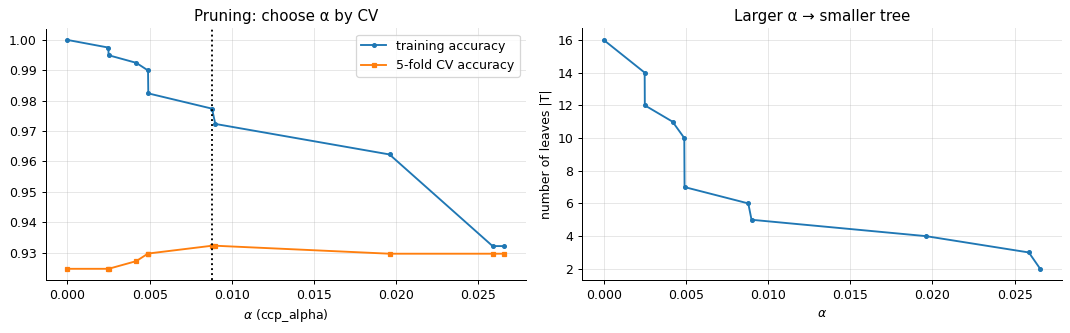

full tree  :  16 leaves, train acc 1.000, test acc 0.906
pruned tree:   6 leaves, train acc 0.977, test acc 0.918


In [8]:
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split, cross_val_score

Xc, yc = load_breast_cancer(return_X_y=True)
Xtr, Xte, ytr, yte = train_test_split(Xc, yc, test_size=0.3, stratify=yc, random_state=0)

path = DecisionTreeClassifier(random_state=0).cost_complexity_pruning_path(Xtr, ytr)
alphas = path.ccp_alphas[:-1]
tr_acc, cv_acc, leaves = [], [], []
for a in alphas:
    t = DecisionTreeClassifier(ccp_alpha=a, random_state=0)
    cv_acc.append(cross_val_score(t, Xtr, ytr, cv=5).mean())
    t.fit(Xtr, ytr); tr_acc.append(t.score(Xtr, ytr)); leaves.append(t.get_n_leaves())
best_a = alphas[int(np.argmax(cv_acc))]

fig, axes = plt.subplots(1, 2, figsize=(12, 3.8))
axes[0].plot(alphas, tr_acc, "o-", ms=3, label="training accuracy"); axes[0].plot(alphas, cv_acc, "s-", ms=3, label="5-fold CV accuracy")
axes[0].axvline(best_a, color="k", ls=":"); axes[0].set_xlabel(r"$\alpha$ (ccp_alpha)"); axes[0].legend(); axes[0].set_title("Pruning: choose α by CV")
axes[1].plot(alphas, leaves, "o-", ms=3); axes[1].set_xlabel(r"$\alpha$"); axes[1].set_ylabel("number of leaves |T|"); axes[1].set_title("Larger α → smaller tree")
plt.tight_layout(); plt.show()

full = DecisionTreeClassifier(random_state=0).fit(Xtr, ytr)
pruned = DecisionTreeClassifier(ccp_alpha=best_a, random_state=0).fit(Xtr, ytr)
print(f"full tree  : {full.get_n_leaves():3d} leaves, train acc {full.score(Xtr, ytr):.3f}, test acc {full.score(Xte, yte):.3f}")
print(f"pruned tree: {pruned.get_n_leaves():3d} leaves, train acc {pruned.score(Xtr, ytr):.3f}, test acc {pruned.score(Xte, yte):.3f}")

## 10. Properties

**Strengths**
- Easy to read and explain (a small tree is a set of if/else rules).
- **No feature scaling needed**, and invariant to any monotone transformation of a feature (only the order of values matters).
- Handle mixed numeric/categorical features, and capture non-linear effects and interactions automatically.
- Fast to train and predict.

**Weaknesses**
- **High variance / instability**: a small change in the data can change the top split and therefore the whole tree (see below).
- Axis-aligned, piecewise-constant: staircase boundaries, can't extrapolate (the prediction outside the training range is the last leaf's constant).
- Greedy, so not globally optimal.

The fix for the variance is to **average many trees** (notebook 07).

**Feature importance (MDI).** For each feature, add up the (size-weighted) impurity decreases $N_t\Delta I$ of all nodes that split on it, then normalise to sum to 1 (`feature_importances_`). Cheap, but biased towards features with many possible thresholds; permutation importance on validation data is more reliable.

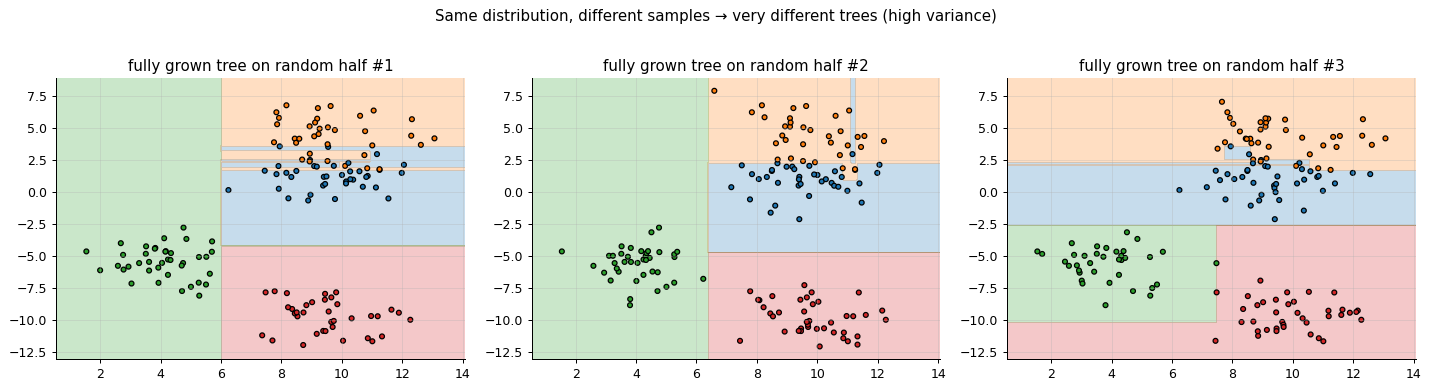

In [9]:
# Instability: trees grown on two random halves of the same data
fig, axes = plt.subplots(1, 3, figsize=(16, 4.2))
for ax, seed in zip(axes, [1, 2, 3]):
    idx = np.random.default_rng(seed).choice(len(yb), len(yb) // 2, replace=False)
    t = DecisionTreeClassifier(random_state=0).fit(Xb[idx], yb[idx])
    Z = t.predict(G).reshape(g1.shape)
    ax.contourf(g1, g2, Z, alpha=0.25, levels=[-0.5, 0.5, 1.5, 2.5, 3.5], cmap="tab10", vmin=0, vmax=9)
    ax.scatter(Xb[idx, 0], Xb[idx, 1], c=yb[idx], cmap="tab10", vmin=0, vmax=9, edgecolor="k", s=15)
    ax.set_title(f"fully grown tree on random half #{seed}")
plt.suptitle("Same distribution, different samples → very different trees (high variance)", y=1.02)
plt.tight_layout(); plt.show()

## Summary

- A tree partitions the space into axis-aligned boxes and predicts a constant per box (mean, majority class, or class proportions).
- CART grows it greedily: at each node, pick the feature/threshold with the largest size-weighted impurity decrease (Gini/entropy for classification, variance = SSE for regression).
- Unrestricted trees overfit; control them with stopping rules or cost-complexity pruning $R(T)+\alpha|T|$, with $\alpha$ chosen by CV.
- Interpretable, scale-free and fast, but high-variance, which motivates bagging and random forests.